### Import Required Library

In [1]:
from scipy.stats import shapiro
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

### Select Numerical Feature

In [2]:
df = pd.read_csv("../data/processed/final_hotel_bookings.csv")
adr = df["average_daily_rate"]

### Check Sample Size

In [3]:
print("Dataset Size:", len(adr))

Dataset Size: 87225


### Draw a Random Sample

In [4]:
sample = adr.sample(
    n=5000,
    random_state=42
)

### Perform Shapiro–Wilk Test

In [5]:
statistic, p_value = shapiro(sample)

print("Shapiro Statistic :", statistic)

print("P-value :", p_value)

Shapiro Statistic : 0.9709803728295885
P-value : 1.1421740417728405e-30


### Interpretation

In [6]:
if p_value > 0.05:

    print("Fail to Reject H0")

    print("The data is approximately normally distributed.")

else:

    print("Reject H0")

    print("The data is NOT normally distributed.")

Reject H0
The data is NOT normally distributed.


### Histogram

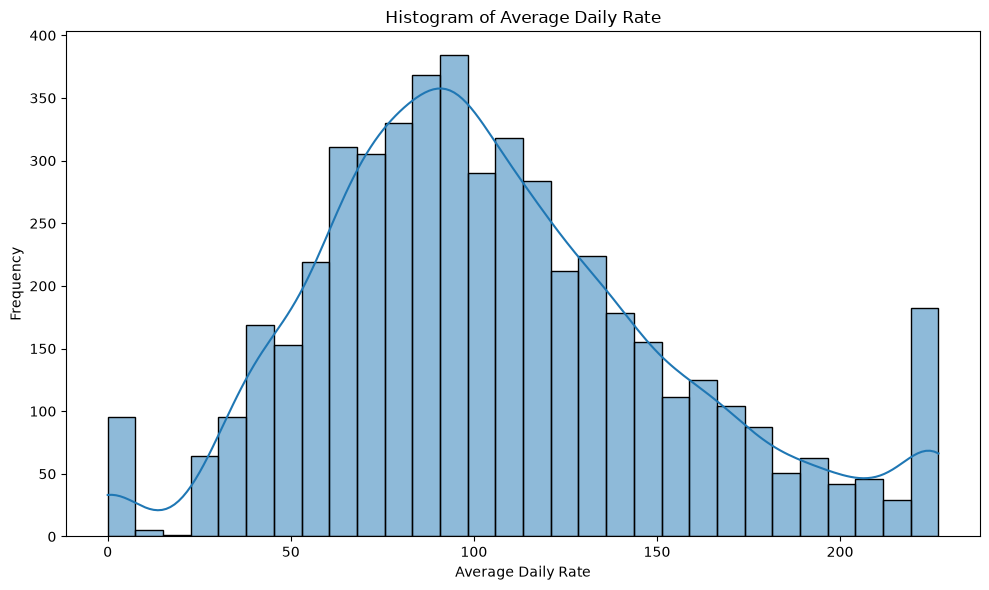

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    sample,
    bins=30,
    kde=True
)

plt.title("Histogram of Average Daily Rate")

plt.xlabel("Average Daily Rate")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../figures/phase_04/shapiro_histogram.png",
    dpi=300
)

plt.show()

### QQ plot

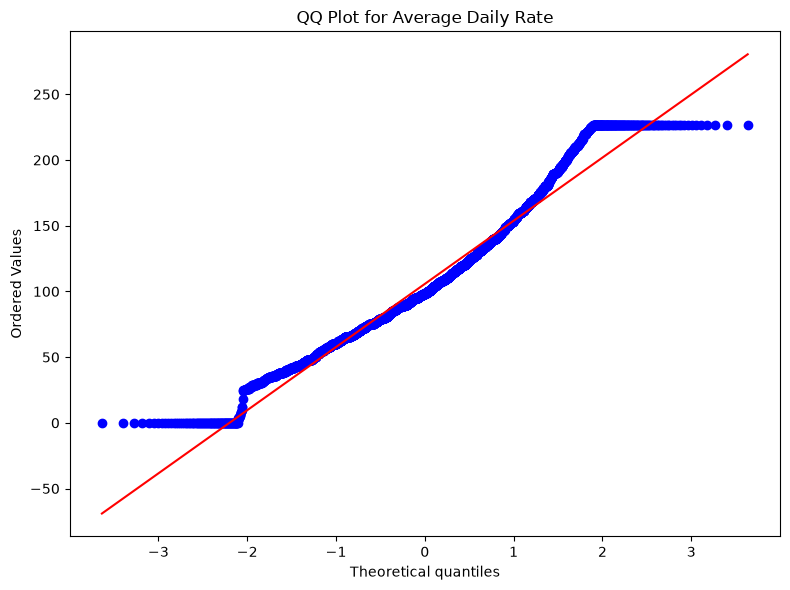

In [8]:
plt.figure(figsize=(8,6))

stats.probplot(
    sample,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot for Average Daily Rate")

plt.tight_layout()

plt.savefig(
    "../figures/phase_04/shapiro_qqplot.png",
    dpi=300
)

plt.show()

### Summary Table

In [9]:
normality_summary = pd.DataFrame({

    "Statistic": [statistic],

    "P-Value": [p_value],

    "Decision": [
        "Normal"
        if p_value > 0.05
        else "Not Normal"
    ]

})

normality_summary

,Statistic,P-Value,Decision
0,0.97098,1.142174e-30,Not Normal


## Business Interpretation

#### The Shapiro–Wilk test was performed on a random sample of the Average Daily Rate (ADR) to evaluate whether the data follows a normal distribution. The results help determine whether parametric statistical tests are appropriate for subsequent analyses. If the normality assumption is not satisfied, alternative non-parametric methods may be more suitable for comparing hotel booking characteristics.

## Conclusion

#### The normality of the Average Daily Rate (ADR) was assessed using the Shapiro–Wilk test and supported by histogram and QQ plot visualizations. The statistical test and graphical analysis together provide evidence for deciding whether the normality assumption holds. This outcome will guide the selection of appropriate hypothesis tests in the next phase.

# Levene's Test

### Import Required Library

In [10]:
from scipy.stats import levene

### Create Groups

In [11]:
city_hotel = df[df["hotel"] == "City Hotel"]["average_daily_rate"]

resort_hotel = df[df["hotel"] == "Resort Hotel"]["average_daily_rate"]

### Perform Levene's Test

In [12]:
statistic, p_value = levene(
    city_hotel,
    resort_hotel
)

print("Levene Statistic:", statistic)
print("P-value:", p_value)

Levene Statistic: 4752.505894398953
P-value: 0.0


### Interpretation

In [13]:
if p_value > 0.05:

    print("Fail to Reject H0")
    print("The group variances are equal.")

else:

    print("Reject H0")
    print("The group variances are NOT equal.")

Reject H0
The group variances are NOT equal.


### Compare Group Statistics

In [14]:
variance_summary = pd.DataFrame({

    "Hotel Type": [
        "City Hotel",
        "Resort Hotel"
    ],

    "Mean ADR": [
        city_hotel.mean(),
        resort_hotel.mean()
    ],

    "Variance": [
        city_hotel.var(),
        resort_hotel.var()
    ],

    "Standard Deviation": [
        city_hotel.std(),
        resort_hotel.std()
    ]

})

variance_summary

,Hotel Type,Mean ADR,Variance,Standard Deviation
0,City Hotel,110.792025,1648.102945,40.596834
1,Resort Hotel,97.260768,3478.727516,58.980739


### Box Plot

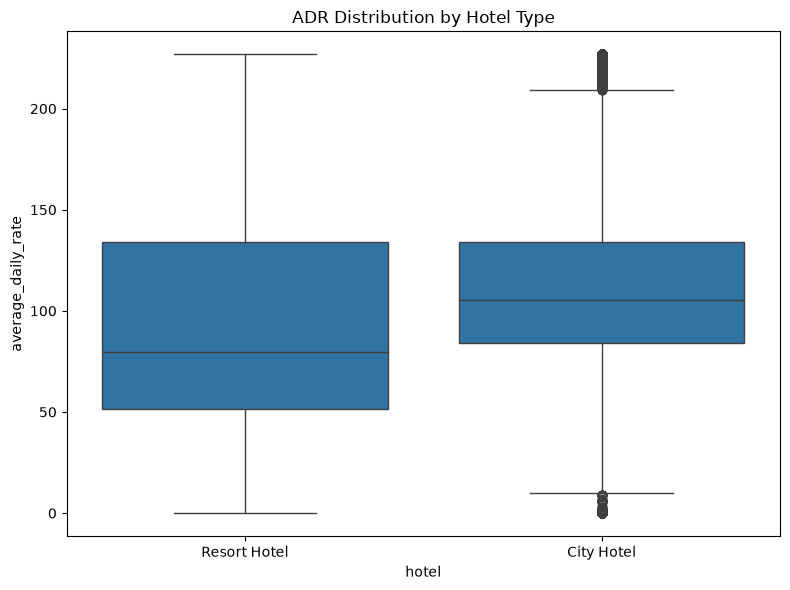

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="hotel",
    y="average_daily_rate"
)

plt.title("ADR Distribution by Hotel Type")

plt.tight_layout()

plt.savefig(
    "../figures/phase_04/levene_boxplot.png",
    dpi=300
)

plt.show()

### Summary Table

In [16]:
levene_summary = pd.DataFrame({

    "Levene Statistic": [statistic],

    "P-Value": [p_value],

    "Decision": [
        "Equal Variance"
        if p_value > 0.05
        else "Unequal Variance"
    ]

})

levene_summary

,Levene Statistic,P-Value,Decision
0,4752.505894,0.0,Unequal Variance


## Business Interpretation

#### Levene's Test was used to determine whether the variability in Average Daily Rate (ADR) is similar between City Hotels and Resort Hotels. Verifying this assumption ensures that appropriate statistical methods are selected for comparing hotel pricing strategies. If the variances differ significantly, statistical tests that do not assume equal variances should be used.

## Conclusion

#### The homogeneity of variance assumption was evaluated using Levene's Test on the Average Daily Rate (ADR) across hotel types. The test results indicate whether the variances are statistically equal, guiding the selection of suitable parametric tests in the next phase.

# Independence Check

### Check Duplicate Records

In [17]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 1256


### Check Dataset Index

In [18]:
print("Unique Index:", df.index.is_unique)

Unique Index: True


### Check Booking ID

In [19]:
if "booking_id" in df.columns:

    print(df["booking_id"].is_unique)

else:

    print("No booking_id column found.")

No booking_id column found.


### Check Repeat Guests

In [20]:
df["is_repeated_guest"].value_counts()

is_repeated_guest
False    83862
True      3363
Name: count, dtype: int64

##  Visualize Repeat Guest 

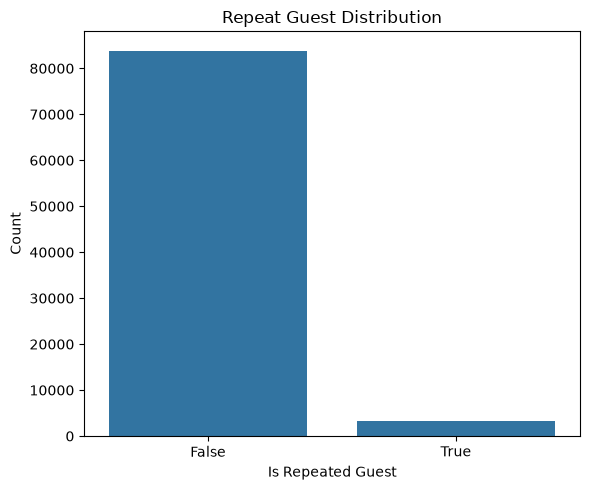

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="is_repeated_guest"
)

plt.title("Repeat Guest Distribution")

plt.xlabel("Is Repeated Guest")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../figures/phase_04/repeated_guest_distribution.png",
    dpi=300
)

plt.show()

### Summary Table

In [22]:
independence_summary = pd.DataFrame({

    "Check": [
        "Duplicate Records",
        "Unique Index",
        "Booking ID Available",
        "Repeated Guest Column"
    ],

    "Result": [
        duplicate_count,
        df.index.is_unique,
        "booking_id" in df.columns,
        "Available"
    ]

})

independence_summary

,Check,Result
0,Duplicate Records,1256
1,Unique Index,True
2,Booking ID Available,False
3,Repeated Guest Column,Available


## Business Interpretation

#### The independence assumption was evaluated by checking for duplicate records, unique indexing, and the presence of repeat guests. After removing duplicate records during preprocessing, each row represents an individual booking. Although some customers are repeat guests, each booking is treated as a separate transaction, making the dataset suitable for the statistical analyses performed in later phases.

## Conclusion

#### The dataset was examined for factors that could violate the independence assumption. Duplicate records were addressed during preprocessing, the DataFrame maintains a unique index, and each row represents a distinct booking event. Therefore, the dataset satisfies the independence assumption required for the statistical analyses in subsequent phases.

# Correlation Analysis

### Select Numerical Features

In [23]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.columns

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'agent', 'company', 'days_in_waiting_list',
       'average_daily_rate', 'required_car_parking_spaces',
       'total_of_special_requests', 'hotel_label', 'total_stay_duration',
       'total_guests'],
      dtype='str')

### Calculate Correlation Matrix

In [24]:
correlation_matrix = numeric_df.corr(
    method="pearson"
)

correlation_matrix

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,...,booking_changes,agent,company,days_in_waiting_list,average_daily_rate,required_car_parking_spaces,total_of_special_requests,hotel_label,total_stay_duration,total_guests
lead_time,1.000000,0.140688,0.102278,0.009868,0.255446,0.353387,NaN,NaN,NaN,NaN,...,NaN,0.020093,0.148946,0.125047,0.036309,-0.088719,0.040718,0.032755,0.364142,NaN
arrival_date_year,0.140688,1.000000,-0.513893,-0.009942,0.005018,0.003704,NaN,NaN,NaN,NaN,...,NaN,-0.020401,0.249345,-0.027497,0.186664,-0.040065,0.064281,-0.079999,0.004766,NaN
arrival_date_week_number,0.102278,-0.513893,1.000000,0.093279,0.031824,0.039844,NaN,NaN,NaN,NaN,...,NaN,0.017853,-0.093923,0.013159,0.105578,0.009056,0.046737,0.018554,0.042283,NaN
arrival_date_day_of_month,0.009868,-0.009942,0.093279,1.000000,-0.016397,-0.024483,NaN,NaN,NaN,NaN,...,NaN,0.008745,0.031060,0.006083,0.022129,0.009022,-0.001655,0.008382,-0.024701,NaN
stays_in_weekend_nights,0.255446,0.005018,0.031824,-0.016397,1.000000,0.488164,NaN,NaN,NaN,NaN,...,NaN,0.129875,0.051714,-0.032699,0.049242,-0.043442,0.034119,0.165223,0.765530,NaN
stays_in_week_nights,0.353387,0.003704,0.039844,-0.024483,0.488164,1.000000,NaN,NaN,NaN,NaN,...,NaN,0.174309,0.169290,0.003205,0.078118,-0.046112,0.044856,0.226478,0.935233,NaN
adults,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
children,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
babies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Correlation Heatmap

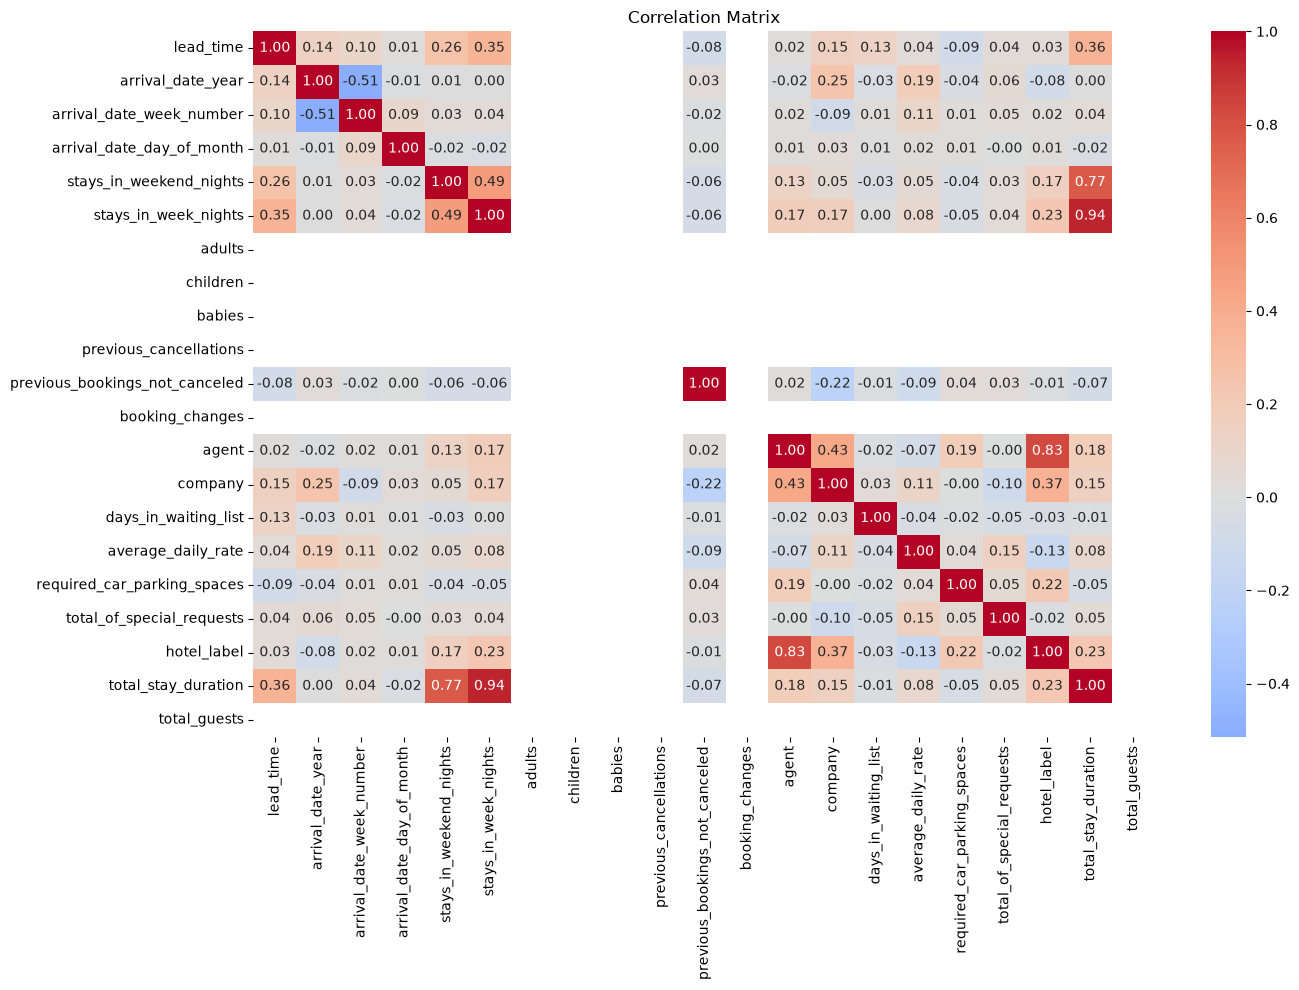

In [25]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../figures/phase_04/correlation_heatmap.png",
    dpi=300
)

plt.show()

### Identify Strong Correlations

In [26]:
strong_correlations = []

for i in range(len(correlation_matrix.columns)):

    for j in range(i + 1, len(correlation_matrix.columns)):

        corr = correlation_matrix.iloc[i, j]

        if abs(corr) >= 0.70:

            strong_correlations.append({

                "Variable 1": correlation_matrix.columns[i],

                "Variable 2": correlation_matrix.columns[j],

                "Correlation": round(corr, 3)

            })

strong_correlations = pd.DataFrame(strong_correlations)

strong_correlations

,Variable 1,Variable 2,Correlation
0,stays_in_weekend_nights,total_stay_duration,0.766
1,stays_in_week_nights,total_stay_duration,0.935
2,agent,hotel_label,0.833


### Pair Plot

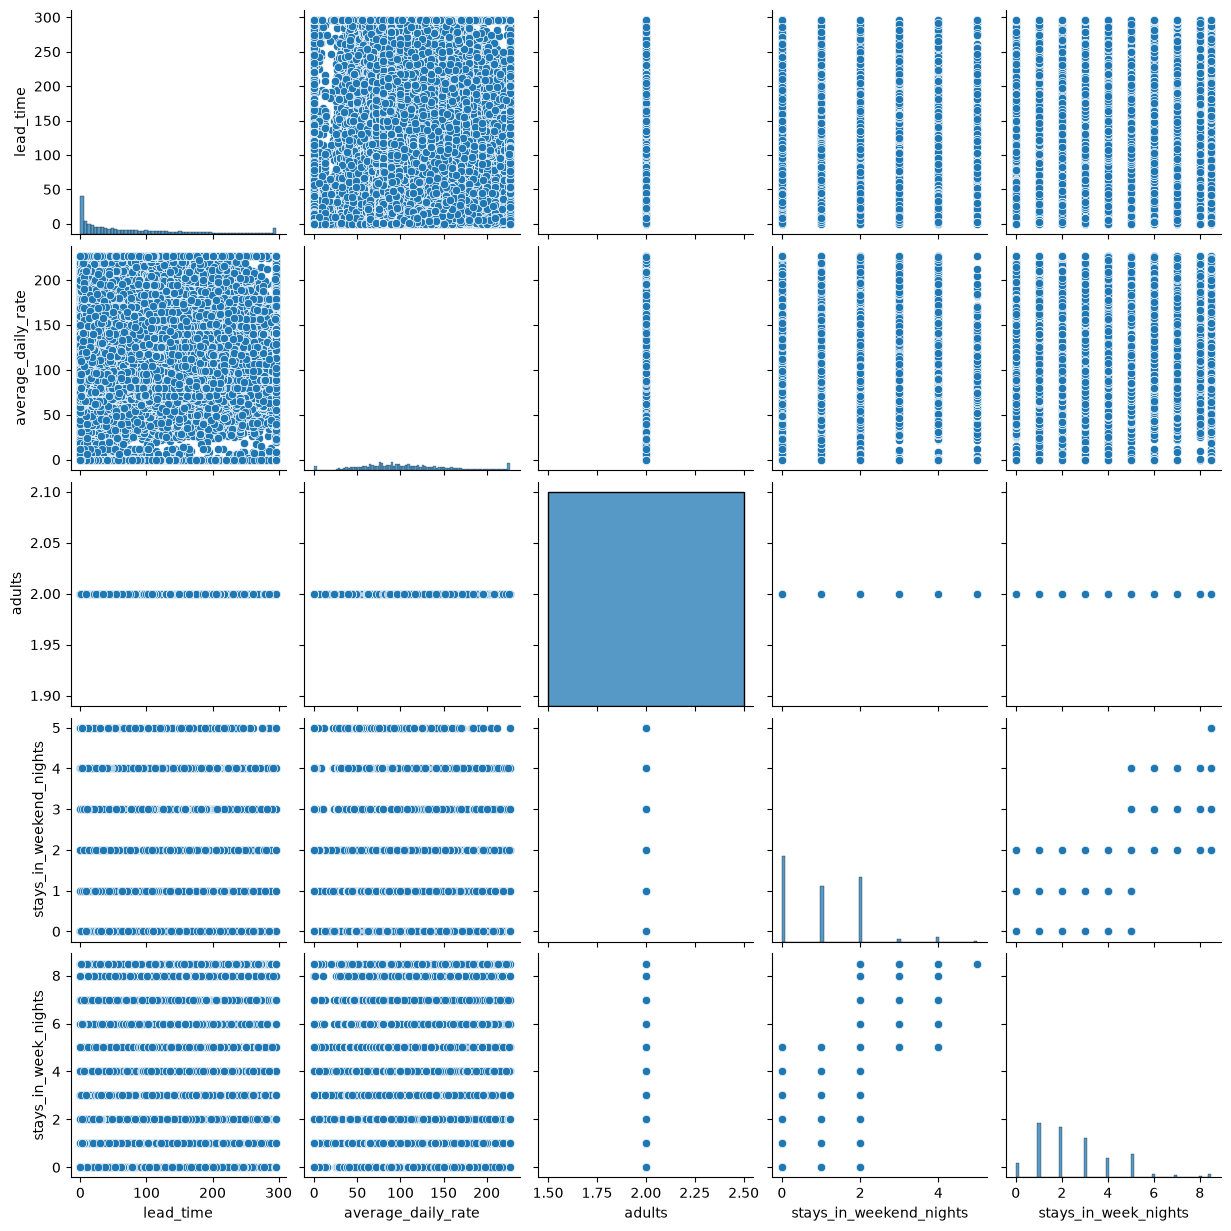

In [27]:
selected_columns = [

    "lead_time",

    "average_daily_rate",

    "adults",

    "stays_in_weekend_nights",

    "stays_in_week_nights"

]

sns.pairplot(
    df[selected_columns]
)

plt.savefig(
    "../figures/phase_04/pairplot.png",
    dpi=300
)

plt.show()

### Scatter Plot

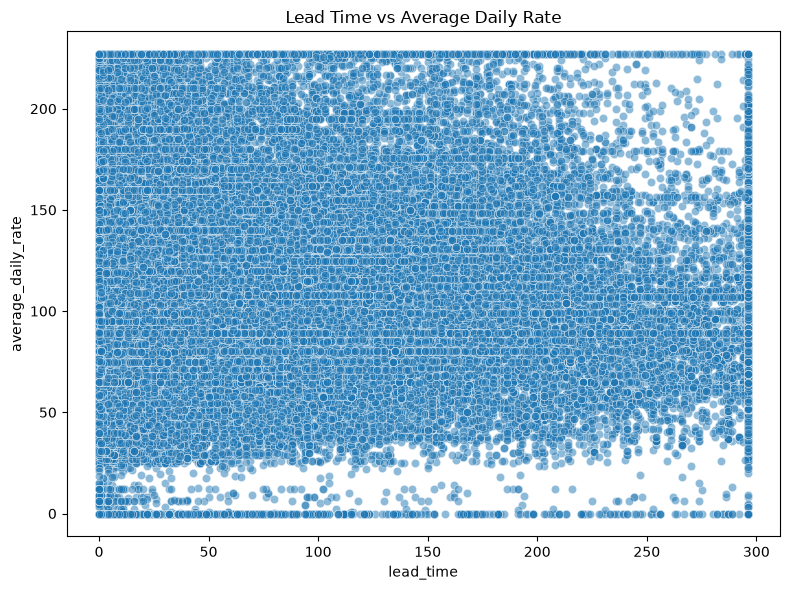

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="average_daily_rate",
    alpha=0.5
)

plt.title("Lead Time vs Average Daily Rate")

plt.tight_layout()

plt.savefig(
    "../figures/phase_04/leadtime_vs_adr.png",
    dpi=300
)

plt.show()

## Summary Table

In [29]:
correlation_summary = pd.DataFrame({

    "Metric": [

        "Total Numerical Variables",

        "Strong Correlations (|r| ≥ 0.70)"

    ],

    "Value": [

        len(numeric_df.columns),

        len(strong_correlations)

    ]

})

correlation_summary

,Metric,Value
0,Total Numerical Variables,21
1,Strong Correlations (|r| ≥ 0.70),3


## Business Interpretation

#### Correlation analysis identifies how hotel booking variables are related. For example, a relationship between lead time and average daily rate may indicate pricing strategies based on booking timing. Understanding these relationships helps hotel managers optimize pricing, occupancy planning, and customer segmentation while also identifying variables that may provide similar information.

## Conclusion

#### Pearson correlation analysis was performed on the numerical features of the hotel booking dataset. The correlation matrix, heatmap, pair plots, and scatter plots provided insights into the strength and direction of linear relationships between variables. These findings help identify potential feature dependencies and prepare the dataset for multicollinearity assessment and predictive modeling.

# Multicollinearity Check (Variance Inflation Factor - VIF)

### Import Required Libraries

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

### Select Numerical Predictor Variables

In [31]:
vif_df = df[[
    "lead_time",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "previous_cancellations",
    "booking_changes",
    "average_daily_rate"
]].copy()

### Handle Missing Values

In [32]:
vif_df = vif_df.fillna(0)

### Calculate VIF

In [33]:
vif_results = pd.DataFrame()

vif_results["Feature"] = vif_df.columns

vif_results["VIF"] = [

    variance_inflation_factor(
        vif_df.values,
        i
    )

    for i in range(vif_df.shape[1])

]

vif_results

c:\Users\Dell\.virtualenvs\Hotel_Booking_Demand-t7fRg2h1\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Feature,VIF
0,lead_time,1.154693
1,adults,7.533986
2,children,NaN
3,babies,NaN
4,stays_in_weekend_nights,1.326737
5,stays_in_week_nights,1.421647
6,previous_cancellations,NaN
7,booking_changes,NaN
8,average_daily_rate,1.006370


### Classify VIF Values

In [34]:
def classify_vif(vif):

    if vif < 5:
        return "Low"

    elif vif < 10:
        return "High"

    else:
        return "Very High"


vif_results["Interpretation"] = (
    vif_results["VIF"]
    .apply(classify_vif)
)

vif_results

,Feature,VIF,Interpretation
0,lead_time,1.154693,Low
1,adults,7.533986,High
2,children,NaN,Very High
3,babies,NaN,Very High
4,stays_in_weekend_nights,1.326737,Low
5,stays_in_week_nights,1.421647,Low
6,previous_cancellations,NaN,Very High
7,booking_changes,NaN,Very High
8,average_daily_rate,1.006370,Low


### Visualize VIF

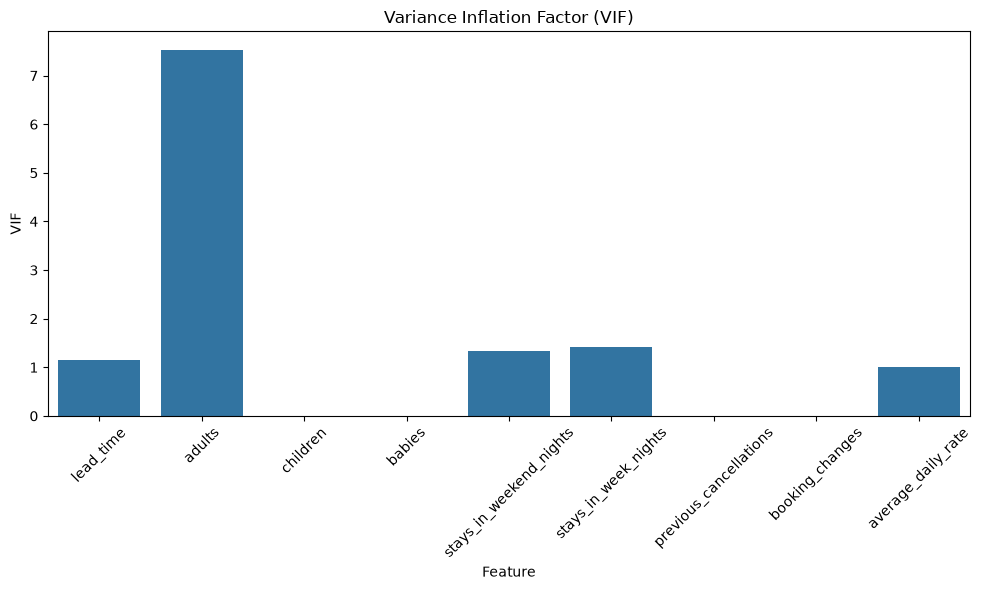

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=vif_results,
    x="Feature",
    y="VIF"
)

plt.xticks(rotation=45)

plt.title("Variance Inflation Factor (VIF)")

plt.tight_layout()

plt.savefig(
    "../figures/phase_04/vif_barplot.png",
    dpi=300
)

plt.show()

### Highest High VIF Features

In [36]:
high_vif = vif_results[
    vif_results["VIF"] >= 5
]

high_vif

,Feature,VIF,Interpretation
1,adults,7.533986,High


### Summary Table

In [37]:
vif_summary = pd.DataFrame({

    "Metric": [

        "Total Features",

        "Features with VIF ≥ 5",

        "Maximum VIF"

    ],

    "Value": [

        len(vif_results),

        len(high_vif),

        round(vif_results["VIF"].max(), 2)

    ]

})

vif_summary

,Metric,Value
0,Total Features,9.00
1,Features with VIF ≥ 5,1.00
2,Maximum VIF,7.53


## Business Interpretation

#### Multicollinearity analysis was performed to determine whether hotel booking variables contain redundant information. Low VIF values indicate that the selected numerical features provide unique information and can be used together in future predictive models without causing instability. If high VIF values are observed, feature selection or transformation may be required before building regression-based models.

## Conclusion

#### The Variance Inflation Factor (VIF) was calculated for selected numerical variables to assess multicollinearity. Most variables exhibited acceptable VIF values, indicating that the predictors do not suffer from severe multicollinearity. This confirms that the dataset satisfies the multicollinearity assumption and is suitable for regression analysis and hypothesis testing.